In [6]:
import time
import scipy
import math
import numpy as np
import numpy.ma as ma
import cmasher as cmr
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

import qutip as qu
from qutip import piqs

plt.style.use('../sty.mplstyle')

In [10]:
def RunQutip(N, t, state, gE, gP, gD, gCE, gCP, gCD):
    [jx, jy, jz] = piqs.jspin(N)
    jp = piqs.jspin(N, "+")
    jm = piqs.jspin(N, "-")
    h  = jz

    system = piqs.Dicke(hamiltonian = h,
               N = N,
               emission = gE,
               pumping = gP,
               dephasing = gD,
               collective_emission = gCE,
               collective_pumping = gCP,
               collective_dephasing = gCD)
    t0 = time.time()
    #lind = system.lindbladian()
    liouv = system.liouvillian()
    t1 = time.time()
    dt = t1-t0
    print("Time (in seconds) to generate the Liouvillian:", dt)

    t0 = time.time()
    result = qu.solver.mesolve(liouv, state, t, [], e_ops = [jx, jz, jp*jm, jm*jp, jx**2, jz**2],
                      options = qu.Options(store_states=True))
    rho = result.states
    jx  = result.expect[0]
    jz  = result.expect[1]
    jpm = result.expect[2]
    jmp = result.expect[3]
    jx2 = result.expect[4]
    jz2 = result.expect[5]
    t1 = time.time()
    dt = t1-t0
    print("Elapsed time (in seconds) for this run: ", dt)
    return jx, jz, jx2, jz2, jpm, jmp, rho


def DickeSpace(blocks, upscale=2):
    N = blocks[0].shape[0] - 1
    j_vals = [N / 2 - i for i in range(N // 2 + 1)]

    m_max = int(N / 2)
    m_grid = np.linspace(-m_max, m_max, num=N + 1)
    pop_matrix = np.zeros((len(m_grid), len(j_vals)))

    for i, (block, j) in enumerate(zip(blocks, j_vals)):
        m_vals = np.flipud(np.arange(-j, j + 1))
        m_idx = (m_vals + m_max).astype(int)
        for idx, m in enumerate(m_vals):
            pop_matrix[m_idx[idx], i] = np.real(block[idx, idx])

    # Interpolate matrix
    pop_matrix_interp = zoom(pop_matrix, zoom=upscale, order=3)  # cubic interpolation

    # Interpolated grids
    m_grid_interp = np.linspace(m_grid[0], m_grid[-1], pop_matrix_interp.shape[0])
    j_vals_interp = np.linspace(j_vals[0], j_vals[-1], pop_matrix_interp.shape[1])

    return j_vals_interp, m_grid_interp, pop_matrix_interp

def DickeEmission(blocks):
    N = blocks[0].shape[0] - 1
    j_vals = [N / 2 - i for i in range(N // 2 + 1)]

    m_max = int(N / 2)
    m_grid = np.linspace(-m_max, m_max, num=N + 1)
    jj_matrix = np.zeros((len(m_grid), len(j_vals)))

    for i, j in enumerate(j_vals):
        m_vals = np.flipud(np.arange(-j, j + 1))
        m_idx = (m_vals + m_max).astype(int)
        for idx, m in enumerate(m_vals):
            jj_value = j * (j + 1) - m * (m - 1)
            jj_matrix[m_idx[idx], i] = jj_value

    return j_vals, m_grid, jj_matrix

In [9]:
N = 30

#state = piqs.dicke(N,N/2,-N/2)      # Dicke basis state
state = piqs.css(N,)                 # Coherent spin state (default +x)

nt = 1001
td0 = np.log(N)/(N*1)
tmax = 20 * td0
tq = np.geomspace(0.0001, tmax, nt)

_, _, jx2_0, _, _, _, state0 = RunQutip(N, tq, state,0,0,0,  1,0.8,0)
_, _, jx2_1, _, _, _, state1 = RunQutip(N, tq, state,0,0,1 , 1,0.8,0)
_, _, jx2_2, _, _, _, state2 = RunQutip(N, tq, state,0,0,100,1,0.8,0)

Time (in seconds) to generate the Liouvillian: 0.02600550651550293
Elapsed time (in seconds) for this run:  5.95266318321228
Time (in seconds) to generate the Liouvillian: 0.027663230895996094
Elapsed time (in seconds) for this run:  6.286397933959961
Time (in seconds) to generate the Liouvillian: 0.027334213256835938
Elapsed time (in seconds) for this run:  13.327622175216675


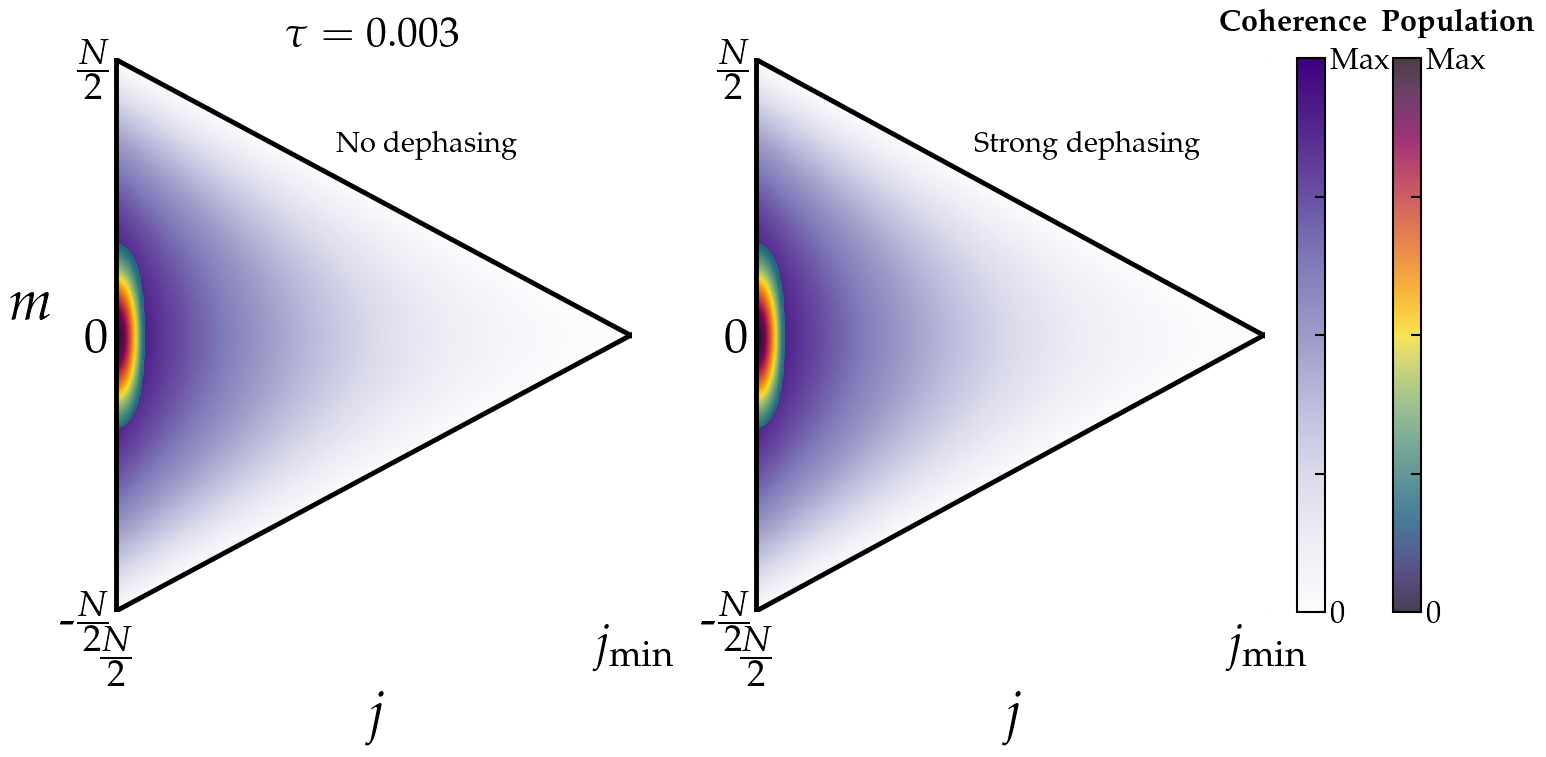

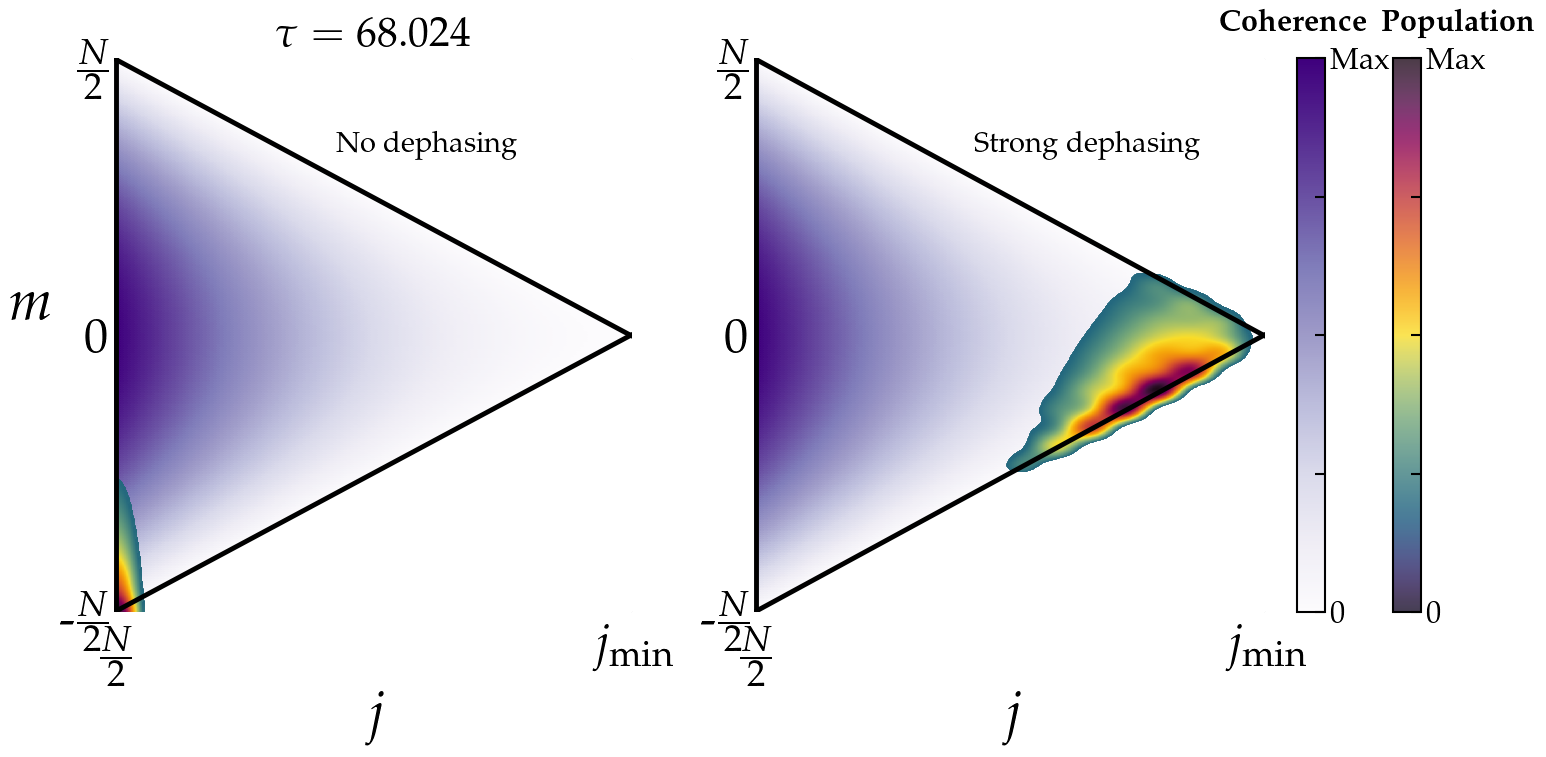

In [12]:
#for j in range(100, len(state0), 5):
for j in [0, -1]:

    map1 = 'Purples'   # coherence
    map2 = cmr.pride   # population
    thr = 0.2
    
    # ----------------------------------------------------------------------------------
    ## Set coherence data
    N2 = 300
    nn = int((N2/2+1)**2)
    statee = np.zeros((nn,nn))
    blocks = piqs.dicke_blocks(statee)
    jD, mD, pD = DickeEmission(blocks)
    pmax = N2**2/4
    masked_pD = ma.masked_where(pD/(pmax) < 1e-6, pD/(pmax))
    # ----------------------------------------------------------------------------------
        
    # ----------------------------------------------------------------------------------
    ## Set population data
    pblocks = piqs.dicke_blocks(state0[j].full().real)
    jj, mm, pp = DickeSpace(pblocks, upscale=50)
    threshold = thr * np.max(pp) 
    pop_nan0 = np.where(pp < threshold, np.nan, pp)
    
    pblocks = piqs.dicke_blocks(state2[j].full().real)
    jj, mm, pp = DickeSpace(pblocks, upscale=50)
    threshold = thr * np.max(pp) 
    pop_nan1 = np.where(pp < threshold, np.nan, pp)
    
    # ----------------------------------------------------------------------------------
    ## plot
    fig, ax = plt.subplots(1,2,figsize=(16, 8), width_ratios=[1,1.45])
    
    cmap = cm.get_cmap(map1).copy()
    cmap.set_bad(color='white')
    
    off = 0
    
    c0 = ax[0].pcolormesh(jD, mD, masked_pD, shading='auto',  cmap=cmap, vmin=0., vmax=1)
    c20 = ax[0].pcolormesh(jj*N2/N, mm*N2/N+off, pop_nan0,  cmap=map2, vmin=0, alpha=0.8)
    
    c1 = ax[1].pcolormesh(jD, mD, masked_pD, shading='auto',  cmap=cmap, vmin=0., vmax=1)
    c21 = ax[1].pcolormesh(jj*N2/N, mm*N2/N+off, pop_nan1,  cmap=map2, vmin=0, alpha=0.8)
    
    
    # colorbar population
    cbar1 = plt.colorbar(c21, pad=0)
    cbar1.set_ticks([0,0.25*np.max(pp),0.5*np.max(pp),0.75*np.max(pp),np.max(pp)])
    cbar1.set_ticklabels(['0','','','','Max'], fontsize=22)
    
    # colorbar coherence
    cbar = plt.colorbar(c1)
    cbar.set_ticklabels(['0','','','', 'Max'], fontsize=22)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
    
    for i in range(len(ax)):
        ax[i].set_xticks([N2/2,0])
        ax[i].set_xticklabels([r'$\frac{N}{2}$', r'$j_{\rm min}$'], fontsize=35)
        ax[i].set_yticks([-N2/2, 0, N2/2])
        ax[i].set_yticklabels([r'-$\frac{N}{2}$', '$0$', r'$\frac{N}{2}$'], fontsize=35)
        ax[i].invert_xaxis()
        ax[i].set_xlabel('$j$', fontsize=40)
    
        jrange = np.linspace(N2/2,-0.5, 100)
        ax[i].plot(jrange, jrange, c='k', lw=3.5)
        ax[i].plot(jrange, -jrange, c='k', lw=3.5)
        ax[i].axvline(N2/2, c='k', lw=3.5)
        
    ax[0].set_ylabel('$m$', rotation=0, labelpad=20, fontsize=40)
    plt.text(13, N2/2+15, r'{\bf Coherence}', fontsize=22)
    plt.text(-35, N2/2+15, r'{\bf Population}', fontsize=22)
    
    ax[0].set_title(r'$\tau=%.3f$'%(tq[j]*N), fontsize=30)
    ax[0].text(N2/3.5,N2/3,'No dephasing', fontsize=21)
    ax[1].text(N2/3.5,N2/3,'Strong dephasing', fontsize=21)
    #ax[1].set_title(r'Strong dephasing', fontsize=30)
    # ax[2].set_title(r'$\tau=%.3f$'%(tq[k]*N), fontsize=30)
    
    for i in range(len(ax)):
        for spine in ax[i].spines.values():
            spine.set_visible(False)
        
        for collection in ax[i].collections:
            collection.set_edgecolor("face")
        ax[i].tick_params(direction='in', length=0.1, width=0.1)
    plt.tight_layout()
    plt.show()
    #fig.savefig('plots/newt_eq/frame_%.3d.png'%int((j-100)/5), bbox_inches='tight', dpi=200)